# Stage 5 — Evidence Scoring, Branch Pruning & ICD-10 Assignment

**Input** : `patient_records/<patient>/admissions/<hadm>/symptom_tree.json`  
**Output**: `stage_05_scored_branches.json` per admission  

## Pipeline position
```
Stage 2: Information Extraction  ✅
Stage 3: Symptom Tree            ✅
Stage 4: Export                  ✅
Stage 5: Evidence Scoring        ← THIS NOTEBOOK
Stage 6: SNOMED Grounding        (planned)
Stage 6b: History Context        (planned)
Stage 7: Final ICD Decision      (planned)
```

## Symptom scoring formula
```
symptom_score = status_weight     (present=1.0, history=0.4, absent=0.0, unknown=0.3)
              + severity_weight   (severe=1.0, moderate=0.7, mild=0.4, unknown=0.5)
              + evidence_bonus    (+0.3 if evidence quote present)
              + lab_bonus         (+0.2 × min(n_findings, 3))
              + red_flag_bonus    (+0.5 if in red_flags)
              + key_symptom_bonus (+0.3 if in key_symptoms)
              + child_bonus       (+0.1 × n_children)

Theoretical range: ~0.4 (absent+mild, no bonuses) → ~3.7 (present+severe+all bonuses)
```

## Branch scoring formula
```
branch_score = 0.7 × max_symptom_score + 0.3 × mean_symptom_score
```
A dominant high-acuity symptom drives the branch rather than being diluted by many mild co-symptoms.

## Pruning strategy (THRESHOLD_MODE — configurable)
| Mode           | Logic                                              | Best for          |
|----------------|----------------------------------------------------|-------------------|
| adaptive_mean  | keep if branch_score >= mean(all branches)         | quick baseline    |
| zscore         | keep if z-score >= ZSCORE_MIN                      | std-aware         |
| fixed          | keep if branch_score >= FIXED_THRESHOLD            | fixed cohort      |
| **hybrid**     | z-score gate + noise floor + max-score safety net  | small/variable N  |

**Hybrid rules (default):**
1. Always prune: branch_score < 0.8 (noise floor — absent/unknown + mild, no bonuses)
2. Always keep:  max_symptom_score >= 2.5 (safety net — present+severe+red_flag+evidence)
3. Otherwise:    keep if z-score >= 0 (above this admission's mean, std-adjusted)

## SNOMED routing
Symptoms with score >= 2.0 are flagged `route_to_snomed=True` for Stage 6 ontology lookup.

## 1. Setup

In [1]:
import json
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Hardcoded absolute path — works regardless of kernel working directory
RECORDS_DIR  = Path(r'C:\Users\esnam\OneDrive\Desktop\esna_master_proj\ai-agents-for-clinical-coding\patient_records')
OUTPUT_STAGE = 'stage_05_evidence_scoring'

print(f'Patient records folder: {RECORDS_DIR}')
print(f'Exists: {RECORDS_DIR.exists()}')
patients = sorted([p for p in RECORDS_DIR.iterdir() if p.is_dir() and p.name.startswith('patient_')])
print(f'Patients found: {len(patients)}')
for p in patients:
    print(f'  {p.name}')

Patient records folder: C:\Users\esnam\OneDrive\Desktop\esna_master_proj\ai-agents-for-clinical-coding\patient_records
Exists: True
Patients found: 15
  patient_10361982
  patient_10426859
  patient_10458324
  patient_11251337
  patient_11474876
  patient_11607177
  patient_12007928
  patient_13196707
  patient_13508515
  patient_13952483
  patient_16014068
  patient_17774110
  patient_18412100
  patient_19104262
  patient_19632936


## 2. Evidence Scoring Functions

In [2]:
# ── Symptom-level scoring weights ─────────────────────────────────────────────
STATUS_WEIGHTS    = {'present': 1.0, 'history': 0.4, 'absent': 0.0, 'unknown': 0.3}
SEVERITY_WEIGHTS  = {'severe': 1.0, 'moderate': 0.7, 'mild': 0.4, 'unknown': 0.5}
EVIDENCE_BONUS    = 0.3   # non-empty evidence quote
LAB_BONUS         = 0.2   # per supporting lab/finding (capped at 3)
RED_FLAG_BONUS    = 0.5   # symptom appears in red_flags
KEY_SYMPTOM_BONUS = 0.3   # symptom appears in key_symptoms
CHILD_BONUS       = 0.1   # per child symptom

# ── Branch scoring formula ─────────────────────────────────────────────────────
# branch_score = 0.7 × max_symptom_score + 0.3 × mean_symptom_score
# A dominant high-acuity symptom drives the branch, not diluted by mild co-symptoms.
BRANCH_MAX_WEIGHT  = 0.7
BRANCH_MEAN_WEIGHT = 0.3

# ── Threshold configuration ────────────────────────────────────────────────────
# Change THRESHOLD_MODE here — no other code needs to change.
#   'adaptive_mean' : keep if branch_score >= mean(all branches)  [original baseline]
#   'zscore'        : keep if z-score >= ZSCORE_MIN               [std-aware relative]
#   'fixed'         : keep if branch_score >= FIXED_THRESHOLD     [absolute, cohort-independent]
#   'hybrid'        : z-score + noise floor + max-score gate      [recommended for small N]
THRESHOLD_MODE   = 'hybrid'

ZSCORE_MIN       = 0.0    # used by 'zscore' and 'hybrid': keep branches at/above mean
FIXED_THRESHOLD  = 2.0    # used by 'fixed': present + moderate + evidence
NOISE_FLOOR      = 0.8    # used by 'hybrid': hard prune below this (absent/unknown + mild)
MAX_SCORE_GATE   = 2.5    # used by 'hybrid': always keep if max symptom >= this value
                           # 2.5 = present + severe + red_flag + evidence

# ── SNOMED routing threshold ───────────────────────────────────────────────────
# Symptoms scoring >= this are flagged route_to_snomed=True for Stage 6 lookup.
# 2.0 = present + moderate + at least one supporting signal.
SNOMED_ROUTING_THRESHOLD = 2.0


def score_symptom(symptom: dict, key_symptoms: list, red_flags: list) -> float:
    """Score a single symptom node."""
    score = 0.0
    status   = str(symptom.get('status',   'unknown')).lower()
    severity = str(symptom.get('severity', 'unknown')).lower()
    score += STATUS_WEIGHTS.get(status, 0.3)
    score += SEVERITY_WEIGHTS.get(severity, 0.5)

    if symptom.get('evidence', ''):
        score += EVIDENCE_BONUS

    related = symptom.get('related_findings', [])
    if isinstance(related, list):
        score += LAB_BONUS * min(len(related), 3)

    term = str(symptom.get('term', '')).lower()
    if any(term in rf.lower() or rf.lower() in term for rf in red_flags):
        score += RED_FLAG_BONUS
    if any(term in ks.lower() or ks.lower() in term for ks in key_symptoms):
        score += KEY_SYMPTOM_BONUS

    children = symptom.get('children', [])
    if isinstance(children, list):
        score += CHILD_BONUS * len(children)

    return round(score, 3)


def score_branch(branch: dict, key_symptoms: list, red_flags: list) -> dict:
    """Score all symptoms in a branch using weighted max+mean formula."""
    symptoms = branch.get('symptoms', [])
    if not isinstance(symptoms, list):
        symptoms = []

    scored_symptoms = []
    for s in symptoms:
        if isinstance(s, dict):
            s_copy = dict(s)
            s_copy['score'] = score_symptom(s, key_symptoms, red_flags)
            s_copy['route_to_snomed'] = s_copy['score'] >= SNOMED_ROUTING_THRESHOLD
            scored_symptoms.append(s_copy)

    if scored_symptoms:
        sym_scores   = [s['score'] for s in scored_symptoms]
        max_score    = max(sym_scores)
        mean_score   = float(np.mean(sym_scores))
        branch_score = round(BRANCH_MAX_WEIGHT * max_score + BRANCH_MEAN_WEIGHT * mean_score, 3)
    else:
        max_score = mean_score = branch_score = 0.0

    return {
        'category'           : branch.get('category', 'unknown'),
        'ontology_hint'      : branch.get('ontology_hint', ''),
        'branch_score'       : branch_score,
        'max_symptom_score'  : round(max_score, 3),
        'mean_symptom_score' : round(mean_score, 3),
        'n_symptoms'         : len(scored_symptoms),
        'n_snomed_routable'  : sum(1 for s in scored_symptoms if s.get('route_to_snomed')),
        'symptoms'           : scored_symptoms,
    }


def _pruning_decision(branch: dict, mean_score: float, std_score: float) -> tuple:
    """Return (keep: bool, reason: str) for one branch under the configured mode."""
    bs = branch['branch_score']
    ms = branch['max_symptom_score']

    if THRESHOLD_MODE == 'adaptive_mean':
        keep = bs >= mean_score
        return keep, ('above_mean' if keep else 'pruned_below_mean')

    elif THRESHOLD_MODE == 'zscore':
        z    = (bs - mean_score) / std_score if std_score > 0 else 0.0
        keep = z >= ZSCORE_MIN
        return keep, (f'kept_z{z:.2f}' if keep else f'pruned_z{z:.2f}')

    elif THRESHOLD_MODE == 'fixed':
        keep = bs >= FIXED_THRESHOLD
        return keep, ('above_fixed' if keep else 'pruned_below_fixed')

    elif THRESHOLD_MODE == 'hybrid':
        # Rule 1 — hard noise floor: always prune truly weak branches
        if bs < NOISE_FLOOR:
            return False, 'pruned_noise_floor'
        # Rule 2 — safety net: never prune high-acuity findings
        if ms >= MAX_SCORE_GATE:
            return True, 'kept_max_gate'
        # Rule 3 — z-score relative to this admission
        z    = (bs - mean_score) / std_score if std_score > 0 else 0.0
        keep = z >= ZSCORE_MIN
        return keep, (f'kept_z{z:.2f}' if keep else f'pruned_z{z:.2f}')

    else:
        raise ValueError(f'Unknown THRESHOLD_MODE: {THRESHOLD_MODE!r}')


def score_symptom_tree(tree: dict) -> dict:
    """Score all branches and apply the configured pruning strategy."""
    key_symptoms = tree.get('key_symptoms', [])
    red_flags    = tree.get('red_flags', [])
    branches     = tree.get('branches', [])
    if not isinstance(branches, list):
        branches = []

    scored_branches = [
        score_branch(b, key_symptoms, red_flags)
        for b in branches if isinstance(b, dict)
    ]

    scores     = [b['branch_score'] for b in scored_branches]
    mean_score = float(np.mean(scores)) if scores else 0.5
    std_score  = float(np.std(scores))  if scores else 0.0

    for b in scored_branches:
        b['keep'], b['keep_reason'] = _pruning_decision(b, mean_score, std_score)
        b['pruned'] = not b['keep']

    kept   = [b for b in scored_branches if b['keep']]
    pruned = [b for b in scored_branches if b['pruned']]

    return {
        'patient_id'           : tree.get('patient_id'),
        'admission_id'         : tree.get('admission_id'),
        'root'                 : tree.get('root'),
        'reasoning'            : tree.get('reasoning'),
        'key_symptoms'         : key_symptoms,
        'red_flags'            : red_flags,
        'threshold_mode'       : THRESHOLD_MODE,
        'prune_threshold_mean' : round(mean_score, 3),
        'prune_threshold_std'  : round(std_score, 3),
        'noise_floor'          : NOISE_FLOOR,
        'max_score_gate'       : MAX_SCORE_GATE,
        'n_branches_total'     : len(scored_branches),
        'n_branches_kept'      : len(kept),
        'n_branches_pruned'    : len(pruned),
        'scored_branches'      : scored_branches,
    }


print(f'Scoring functions defined.')
print(f'Threshold mode       : {THRESHOLD_MODE}')
print(f'Branch formula       : {BRANCH_MAX_WEIGHT} × max_score + {BRANCH_MEAN_WEIGHT} × mean_score')
print(f'Noise floor          : prune if branch_score < {NOISE_FLOOR}')
print(f'Max-score gate       : always keep if max_symptom_score >= {MAX_SCORE_GATE}')
print(f'SNOMED routing       : symptoms with score >= {SNOMED_ROUTING_THRESHOLD} flagged for Stage 6')

Scoring functions defined.
Threshold mode       : hybrid
Branch formula       : 0.7 × max_score + 0.3 × mean_score
Noise floor          : prune if branch_score < 0.8
Max-score gate       : always keep if max_symptom_score >= 2.5
SNOMED routing       : symptoms with score >= 2.0 flagged for Stage 6


## 3. Run Scoring on All 15 Patients

In [3]:
all_scored = []

for patient_dir in patients:
    patient_id = patient_dir.name.replace('patient_', '')
    adm_dirs = sorted((patient_dir / 'admissions').iterdir()) if (patient_dir / 'admissions').exists() else []

    for adm_dir in adm_dirs:
        tree_path = adm_dir / 'symptom_tree.json'
        if not tree_path.exists():
            continue

        with open(tree_path) as f:
            tree = json.load(f)

        scored = score_symptom_tree(tree)

        out_dir = adm_dir / OUTPUT_STAGE
        out_dir.mkdir(exist_ok=True)
        with open(out_dir / 'scored_branches.json', 'w') as f:
            json.dump(scored, f, indent=2, default=str)

        all_scored.append(scored)

        reasons = [b['keep_reason'] for b in scored['scored_branches'] if b['keep']]
        print(f'Patient {patient_id} | Adm {scored["admission_id"]} | '
              f'{scored["n_branches_kept"]}/{scored["n_branches_total"]} kept | '
              f'mean={scored["prune_threshold_mean"]:.2f} std={scored["prune_threshold_std"]:.2f} | '
              f'reasons: {reasons}')

print(f'\nDone. Scored {len(all_scored)} admissions across {len(patients)} patients.')

Patient 10361982 | Adm 24286431 | 1/3 kept | mean=1.90 std=0.51 | reasons: ['kept_max_gate']
Patient 10426859 | Adm 29908281 | 3/4 kept | mean=2.15 std=0.15 | reasons: ['kept_z0.95', 'kept_z0.37', 'kept_z0.37']
Patient 10458324 | Adm 21744342 | 2/3 kept | mean=2.44 std=0.30 | reasons: ['kept_max_gate', 'kept_max_gate']
Patient 11251337 | Adm 29568708 | 3/3 kept | mean=2.88 std=0.03 | reasons: ['kept_max_gate', 'kept_max_gate', 'kept_max_gate']
Patient 11474876 | Adm 29672491 | 1/7 kept | mean=1.22 std=0.38 | reasons: ['kept_z2.41']
Patient 11607177 | Adm 23293838 | 1/2 kept | mean=2.32 std=0.02 | reasons: ['kept_z1.00']
Patient 12007928 | Adm 23749816 | 1/4 kept | mean=2.08 std=0.45 | reasons: ['kept_max_gate']
Patient 13196707 | Adm 21475988 | 3/4 kept | mean=2.31 std=0.42 | reasons: ['kept_max_gate', 'kept_max_gate', 'kept_max_gate']
Patient 13508515 | Adm 21834271 | 3/7 kept | mean=2.04 std=0.26 | reasons: ['kept_max_gate', 'kept_z0.22', 'kept_z1.01']
Patient 13952483 | Adm 23852410

## 4. Visualise Scores for One Patient

Patient    : 10361982
Admission  : 24286431
Reasoning  : The patient presents with heavy vaginal bleeding after a hysterectomy, with a history of abnormal uterine bleeding and previous surgeries.
Key symptoms: ['heavy vaginal bleeding', 'abdominal bloatedness']
Red flags  : []
Threshold  : 1.9 (std=0.51)



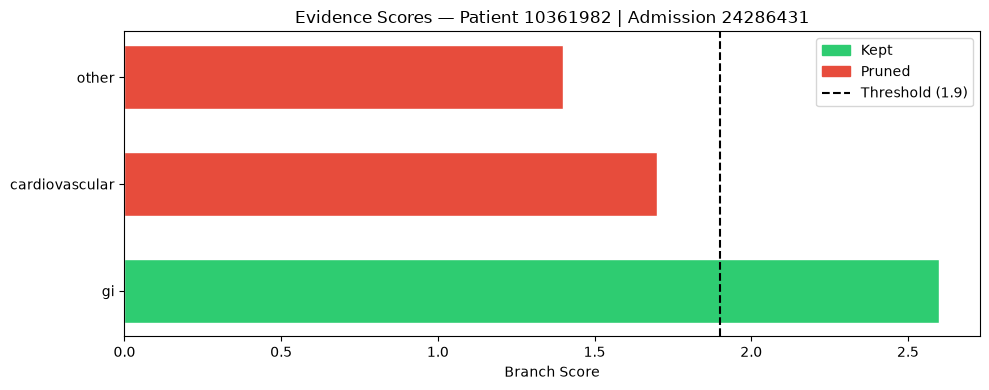


Branch detail:
  [✓ KEEP] gi                   score=2.600  symptoms=1
           heavy vaginal bleeding         status=present  severity=moderate  score=2.600
  [✗ PRUNE] cardiovascular       score=1.700  symptoms=1
           hemodynamic stability          status=present  severity=mild  score=1.700
  [✗ PRUNE] other                score=1.400  symptoms=1
           abdominal bloatedness          status=history  severity=mild  score=1.400


In [4]:
# Change index to inspect a different patient
EXAMPLE_IDX = 0
ex = all_scored[EXAMPLE_IDX]

print(f'Patient    : {ex["patient_id"]}')
print(f'Admission  : {ex["admission_id"]}')
print(f'Reasoning  : {ex["reasoning"]}')
print(f'Key symptoms: {ex["key_symptoms"]}')
print(f'Red flags  : {ex["red_flags"]}')
#print(f'Threshold  : {ex["prune_threshold"]}')
print(f'Threshold  : {ex["prune_threshold_mean"]} (std={ex["prune_threshold_std"]})')
print()

branches = ex['scored_branches']
categories = [b['category'] for b in branches]
scores     = [b['branch_score'] for b in branches]
colors     = ['#2ecc71' if b['keep'] else '#e74c3c' for b in branches]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(categories, scores, color=colors, edgecolor='white', height=0.6)
ax.axvline(ex['prune_threshold_mean'], color='black', linestyle='--', linewidth=1.5, label=f'Threshold ({ex["prune_threshold_mean"]})')
ax.set_xlabel('Branch Score')
ax.set_title(f'Evidence Scores — Patient {ex["patient_id"]} | Admission {ex["admission_id"]}')
kept_patch   = mpatches.Patch(color='#2ecc71', label='Kept')
pruned_patch = mpatches.Patch(color='#e74c3c', label='Pruned')
ax.legend(handles=[kept_patch, pruned_patch, ax.get_legend_handles_labels()[0][0]])
plt.tight_layout()
plt.show()

print('\nBranch detail:')
for b in branches:
    status = '✓ KEEP' if b['keep'] else '✗ PRUNE'
    print(f'  [{status}] {b["category"]:20s} score={b["branch_score"]:.3f}  symptoms={b["n_symptoms"]}')
    for s in b['symptoms']:
        print(f'           {s.get("term",""):30s} status={s.get("status","?")}  severity={s.get("severity","?")}  score={s.get("score",0):.3f}')

## 5. ICD-10 Code Assignment (Kept Branches Only)

In [5]:
import sys
NOTEBOOKS_DIR = Path(r'C:\Users\esnam\OneDrive\Desktop\esna_master_proj\ai-agents-for-clinical-coding\notebooks')
sys.path.insert(0, str(NOTEBOOKS_DIR))

try:
    from pipeline import search_icd10
    ICD_SEARCH_AVAILABLE = True
    print('ICD-10 search available via pipeline.py')
except Exception:
    ICD_SEARCH_AVAILABLE = False
    print('pipeline.py ICD search not available — will use icd10-cm library directly')

if not ICD_SEARCH_AVAILABLE:
    try:
        import icd10
        ICD_LIB_AVAILABLE = True
        print('icd10-cm library available.')
    except ImportError:
        ICD_LIB_AVAILABLE = False
        print('icd10-cm not installed. Run: pip install icd10-cm')

pipeline.py ICD search not available — will use icd10-cm library directly
icd10-cm library available.


In [6]:
def search_codes_for_term(term: str, max_results: int = 5) -> list[dict]:
    """Search ICD-10 codes for a clinical term using icd10-cm library."""
    if not ICD_LIB_AVAILABLE:
        return []

    from collections import defaultdict
    query_words = [w.lower().strip('(),.-') for w in term.split() if len(w) >= 3]
    score_map = defaultdict(int)

    for raw_code, (billable, description) in icd10.codes.items():
        desc_lower = description.lower()
        for word in query_words:
            if word in desc_lower:
                score_map[raw_code] += 1
        if term.lower() in desc_lower:
            score_map[raw_code] += 3

    ranked = sorted(score_map.items(), key=lambda x: x[1], reverse=True)[:max_results]
    results = []
    for raw_code, score in ranked:
        billable, description = icd10.codes[raw_code]
        formatted = raw_code[:3] + ('.' + raw_code[3:] if len(raw_code) > 3 else '')
        results.append({
            'code': formatted,
            'description': description,
            'billable': billable,
            'match_score': score
        })
    return results


def assign_icd_codes_to_branches(scored_result: dict) -> list[dict]:
    """For each kept branch, search ICD-10 codes for its top symptoms."""
    assignments = []

    kept_branches = [b for b in scored_result['scored_branches'] if b['keep']]

    for branch in kept_branches:
        symptoms = sorted(branch['symptoms'], key=lambda s: s.get('score', 0), reverse=True)
        branch_codes = []

        for symptom in symptoms[:3]:
            term = symptom.get('term', '')
            if not term:
                continue
            codes = search_codes_for_term(term, max_results=3)
            if codes:
                branch_codes.append({
                    'symptom'      : term,
                    'symptom_score': symptom.get('score', 0),
                    'status'       : symptom.get('status', ''),
                    'evidence'     : symptom.get('evidence', ''),
                    'icd_candidates': codes
                })

        assignments.append({
            'category'    : branch['category'],
            'branch_score': branch['branch_score'],
            'symptom_codes': branch_codes
        })

    return assignments

print('ICD assignment functions defined.')

ICD assignment functions defined.


In [7]:
# Run ICD assignment on the example patient
assignments = assign_icd_codes_to_branches(ex)

print(f'ICD ASSIGNMENTS — Patient {ex["patient_id"]} | Admission {ex["admission_id"]}')
print('=' * 80)

for branch in assignments:
    print(f'\nBRANCH: {branch["category"].upper()}  (score={branch["branch_score"]})')
    for entry in branch['symptom_codes']:
        print(f'  Symptom: {entry["symptom"]}  [{entry["status"]}]  score={entry["symptom_score"]}')
        print(f'  Evidence: "{entry["evidence"][:80]}"')
        print(f'  ICD candidates:')
        for code in entry['icd_candidates']:
            print(f'    {code["code"]:10s} {code["description"]}')

ICD ASSIGNMENTS — Patient 10361982 | Admission 24286431

BRANCH: GI  (score=2.6)
  Symptom: heavy vaginal bleeding  [present]  score=2.6
  Evidence: "heavy vaginal bleeding after hysterectomy"
  ICD candidates:
    N93        Other abnormal uterine and vaginal bleeding
    N93.1      Pre-pubertal vaginal bleeding
    N93.8      Other specified abnormal uterine and vaginal bleeding


## 6. Evaluate Against Ground Truth

In [8]:
def load_ground_truth(patient_dir: Path, hadm_id: str) -> list[str]:
    """Load ground truth ICD codes for a given admission."""
    gt_path = patient_dir / 'admissions' / f'hadm_{hadm_id}' / 'ground_truth.txt'
    if not gt_path.exists():
        return []
    codes = []
    with open(gt_path, encoding='utf-8') as f:
        for line in f:
            # Lines look like: "   1. A419 — Sepsis, unspecified organism"
            line = line.strip()
            if line and line[0].isdigit() and '—' in line:
                code = line.split('—')[0].split('.')[-1].strip().split()[0].upper()
                if code:
                    codes.append(code)
    return codes


def evaluate_assignment(assignments: list[dict], ground_truth: list[str]) -> dict:
    """Compare predicted ICD codes against ground truth."""
    predicted = set()
    for branch in assignments:
        for entry in branch['symptom_codes']:
            for code in entry['icd_candidates']:
                # Normalize: remove dots for comparison
                predicted.add(code['code'].replace('.', '').upper())

    gt_set = set(c.upper() for c in ground_truth)

    tp = predicted & gt_set
    fp = predicted - gt_set
    fn = gt_set - predicted

    precision = len(tp) / len(predicted) if predicted else 0.0
    recall    = len(tp) / len(gt_set) if gt_set else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'predicted'      : sorted(predicted),
        'ground_truth'   : sorted(gt_set),
        'true_positives' : sorted(tp),
        'false_positives': sorted(fp),
        'false_negatives': sorted(fn),
        'precision'      : round(precision, 3),
        'recall'         : round(recall, 3),
        'f1'             : round(f1, 3),
    }

print('Evaluation functions defined.')

Evaluation functions defined.


In [9]:
# Evaluate the example patient
patient_dir_ex = RECORDS_DIR / f'patient_{ex["patient_id"]}'
gt = load_ground_truth(patient_dir_ex, ex['admission_id'])

print(f'Ground truth codes ({len(gt)}): {gt}')
metrics = evaluate_assignment(assignments, gt)

print(f'\nPredicted codes ({len(metrics["predicted"])}): {metrics["predicted"]}')
print(f'True positives : {metrics["true_positives"]}')
print(f'False positives: {metrics["false_positives"]}')
print(f'False negatives: {metrics["false_negatives"]}')
print(f'\nPrecision : {metrics["precision"]}')
print(f'Recall    : {metrics["recall"]}')
print(f'F1 Score  : {metrics["f1"]}')

Ground truth codes (5): ['N99820', 'Y836', 'Y92009', 'E039', 'F909']

Predicted codes (3): ['N93', 'N931', 'N938']
True positives : []
False positives: ['N93', 'N931', 'N938']
False negatives: ['E039', 'F909', 'N99820', 'Y836', 'Y92009']

Precision : 0.0
Recall    : 0.0
F1 Score  : 0.0


In [10]:
# Evaluate ALL 15 patients and summarise
all_metrics = []

for scored in all_scored:
    pid   = scored['patient_id']
    hadm  = scored['admission_id']
    patient_dir_i = RECORDS_DIR / f'patient_{pid}'

    gt_codes = load_ground_truth(patient_dir_i, hadm)
    if not gt_codes:
        continue

    assign = assign_icd_codes_to_branches(scored)
    m = evaluate_assignment(assign, gt_codes)
    m['patient_id']  = pid
    m['admission_id'] = hadm
    m['n_gt_codes']   = len(gt_codes)
    m['n_predicted']  = len(m['predicted'])
    all_metrics.append(m)

    # Save per-admission evaluation
    out_dir = patient_dir_i / 'admissions' / f'hadm_{hadm}' / OUTPUT_STAGE
    out_dir.mkdir(exist_ok=True)
    with open(out_dir / 'evaluation.json', 'w') as f:
        json.dump(m, f, indent=2)

# Summary table
df = pd.DataFrame(all_metrics)[['patient_id', 'admission_id', 'n_gt_codes', 'n_predicted', 'precision', 'recall', 'f1']]
print(df.to_string(index=False))
print(f'\nMean Precision : {df["precision"].mean():.3f}')
print(f'Mean Recall    : {df["recall"].mean():.3f}')
print(f'Mean F1        : {df["f1"].mean():.3f}')

patient_id admission_id  n_gt_codes  n_predicted  precision  recall    f1
  10361982     24286431           5            3      0.000   0.000 0.000
  10426859     29908281          22           10      0.000   0.000 0.000
  10458324     21744342          12           12      0.167   0.167 0.167
  11251337     29568708           7           12      0.000   0.000 0.000
  11474876     29672491          17            6      0.000   0.000 0.000
  11607177     23293838          13            9      0.000   0.000 0.000
  12007928     23749816          19            9      0.000   0.000 0.000
  13196707     21475988          32           15      0.000   0.000 0.000
  13508515     21834271          14            9      0.111   0.071 0.087
  13952483     23852410          25           12      0.000   0.000 0.000
  16014068     29042843          19            6      0.000   0.000 0.000
  17774110     27339772          29           18      0.056   0.034 0.043
  18412100     26093939           8   

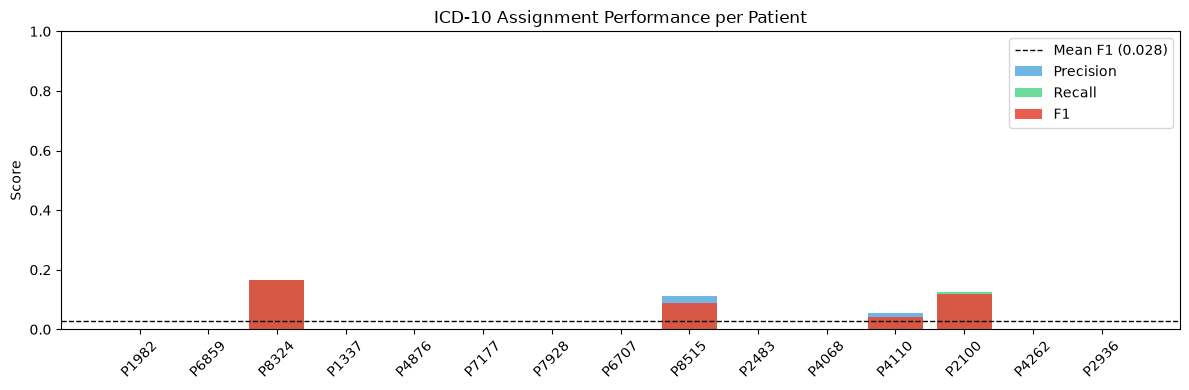

In [11]:
# Plot F1 per patient
fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(df))
ax.bar(x, df['precision'], label='Precision', color='#3498db', alpha=0.7)
ax.bar(x, df['recall'],    label='Recall',    color='#2ecc71', alpha=0.7)
ax.bar(x, df['f1'],        label='F1',        color='#e74c3c', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([f'P{m["patient_id"][-4:]}' for m in all_metrics], rotation=45)
ax.set_ylim(0, 1.0)
ax.axhline(df['f1'].mean(), color='black', linestyle='--', linewidth=1, label=f'Mean F1 ({df["f1"].mean():.3f})')
ax.legend()
ax.set_title('ICD-10 Assignment Performance per Patient')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

## 7. Save Full Results

In [12]:
summary = {
    'n_patients'       : len(patients),
    'n_admissions'     : len(all_metrics),
    'mean_precision'   : round(df['precision'].mean(), 3),
    'mean_recall'      : round(df['recall'].mean(), 3),
    'mean_f1'          : round(df['f1'].mean(), 3),
    'scoring_weights'  : {
        'status'     : STATUS_WEIGHTS,
        'severity'   : SEVERITY_WEIGHTS,
        'evidence_bonus'    : EVIDENCE_BONUS,
        'lab_bonus'         : LAB_BONUS,
        'red_flag_bonus'    : RED_FLAG_BONUS,
        'key_symptom_bonus' : KEY_SYMPTOM_BONUS,
        'child_bonus'       : CHILD_BONUS,
    },
    'per_patient'      : all_metrics
}

out_path = RECORDS_DIR / 'stage_05_summary.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print(f'Saved: {out_path}')
print(f'\nFinal Results:')
print(f'  Mean Precision : {summary["mean_precision"]}')
print(f'  Mean Recall    : {summary["mean_recall"]}')
print(f'  Mean F1        : {summary["mean_f1"]}')

Saved: C:\Users\esnam\OneDrive\Desktop\esna_master_proj\ai-agents-for-clinical-coding\patient_records\stage_05_summary.json

Final Results:
  Mean Precision : 0.03
  Mean Recall    : 0.026
  Mean F1        : 0.028
